In [487]:
# Imports

import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np
from sklearn.preprocessing import PowerTransformer, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso 
import joblib
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer


In [454]:
# Load Data 

df = pd.read_csv("/Users/lydialichen/real_estate/real-estate-ml/data/raw/UK-HPI-full-file-2025-04.csv")

In [455]:
# Basic Overview 

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145845 entries, 0 to 145844
Data columns (total 54 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Date                    145845 non-null  object 
 1   RegionName              145845 non-null  object 
 2   AreaCode                145845 non-null  object 
 3   AveragePrice            145845 non-null  int64  
 4   Index                   145845 non-null  float64
 5   IndexSA                 5124 non-null    float64
 6   1m%Change               145392 non-null  float64
 7   12m%Change              140985 non-null  float64
 8   AveragePriceSA          5124 non-null    float64
 9   SalesVolume             141378 non-null  float64
 10  DetachedPrice           139140 non-null  float64
 11  DetachedIndex           139140 non-null  float64
 12  Detached1m%Change       138745 non-null  float64
 13  Detached12m%Change      134424 non-null  float64
 14  SemiDetachedPrice   

,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,DetachedPrice,DetachedIndex,Detached1m%Change,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
count,1.458450e+05,145845.000000,5124.000000,145392.000000,140985.000000,5124.000000,141378.000000,1.391400e+05,139140.000000,138745.000000,...,1.385120e+05,138512.000000,138116.000000,133784.000000,135890.000000,1.387160e+05,138716.000000,138320.000000,133988.000000,138704.000000
mean,1.803891e+05,58.921199,61.213973,0.535874,6.202777,166289.683060,1252.199402,3.368150e+05,59.020706,0.471254,...,2.162370e+05,60.698833,0.528737,6.327621,136.268732,1.820616e+05,59.133448,0.478803,6.143602,1136.464334
std,1.295248e+05,26.174054,24.588054,1.943991,8.684222,93484.696862,7704.955758,3.380247e+05,24.728221,1.706120,...,1.321695e+05,25.868592,1.793981,8.059877,846.323121,1.292576e+05,25.048355,1.736337,8.471461,6957.107124
min,2.553000e+03,0.800000,13.900000,-30.300000,-35.800000,39008.000000,2.000000,4.011700e+04,9.400000,-19.600000,...,2.244300e+04,8.000000,-29.800000,-28.900000,1.000000,2.271600e+04,9.000000,-30.600000,-30.300000,2.000000
25%,9.916900e+04,36.800000,45.400000,-0.400000,1.200000,114236.750000,140.000000,1.765838e+05,40.100000,-0.500000,...,1.258485e+05,41.100000,-0.500000,1.700000,10.000000,1.008618e+05,39.600000,-0.500000,1.100000,126.000000
50%,1.523680e+05,60.500000,61.800000,0.500000,5.200000,151301.000000,215.000000,2.565430e+05,59.400000,0.500000,...,1.954325e+05,61.000000,0.500000,5.500000,21.000000,1.527225e+05,60.200000,0.500000,5.200000,193.000000
75%,2.266620e+05,79.000000,79.400000,1.500000,10.300000,205126.000000,377.000000,3.893742e+05,78.400000,1.400000,...,2.730998e+05,81.200000,1.500000,10.200000,47.000000,2.270355e+05,78.200000,1.400000,10.300000,343.000000
max,1.656986e+06,153.100000,112.900000,35.300000,98.400000,574627.000000,183609.000000,5.820174e+06,147.000000,34.800000,...,1.414204e+06,149.600000,34.900000,96.200000,21097.000000,1.665089e+06,152.700000,35.600000,98.600000,166098.000000


For the hedonic real estate model, we focus on data from the most recent 2 years (24 months) to capture relevant market conditions amid rapidly changing economic factors such as interest rates, inflation, and post-pandemic shifts. This timeframe balances having enough data to identify seasonal and market trends while ensuring the model reflects the current real estate environment in 2025
A general rule of thumb: At least 10-30 observations per feature in a regression model are required. So for 44 variables using 30 obs/feature: we need a minimum of 1320 rows. 1320 < 6480 rows, so in principle that is enough.

In [456]:
#Convert date column to pandas datetime format 
df["Date"] = pd.to_datetime(df["Date"], format = "%d/%m/%Y")
df["Date"].head()

0   2004-01-01
1   2004-02-01
2   2004-03-01
3   2004-04-01
4   2004-05-01
Name: Date, dtype: datetime64[ns]

In [457]:
#Display number of missing instances per column 
df.isnull().sum().sort_values(ascending = False) #find missing values


IndexSA                   140721
AveragePriceSA            140721
Cash12m%Change             87829
Mortgage12m%Change         87829
FOO12m%Change              87829
FTB12m%Change              87433
CashSalesVolume            83911
MortgageSalesVolume        83911
Cash1m%Change              83517
Mortgage1m%Change          83517
FOO1m%Change               83517
MortgagePrice              83125
MortgageIndex              83125
CashPrice                  83125
CashIndex                  83125
FOOIndex                   83125
FOOPrice                   83125
FTB1m%Change               83121
FTBIndex                   82729
FTBPrice                   82729
New12m%Change              12061
Old12m%Change              11857
Detached12m%Change         11421
SemiDetached12m%Change     11421
Terraced12m%Change         11322
Flat12m%Change             11069
NewSalesVolume              9955
New1m%Change                7729
Old1m%Change                7525
NewPrice                    7333
NewIndex  

Text(0, 0.5, 'Frequency')

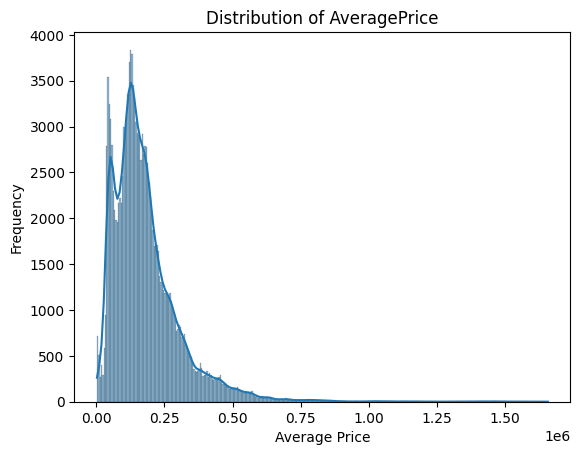

In [458]:
#check if the distribution is skewed, to decide whether not to apply log transformation, and overlaying a smooth density curve
sns.histplot(df["AveragePrice"], kde = True)
plt.title("Distribution of AveragePrice")
plt.xlabel("Average Price")
plt.ylabel("Frequency")


Observations from the graph: the peak is near the left, and tail extends right -> Right skew

Text(0, 0.5, 'Frequency')

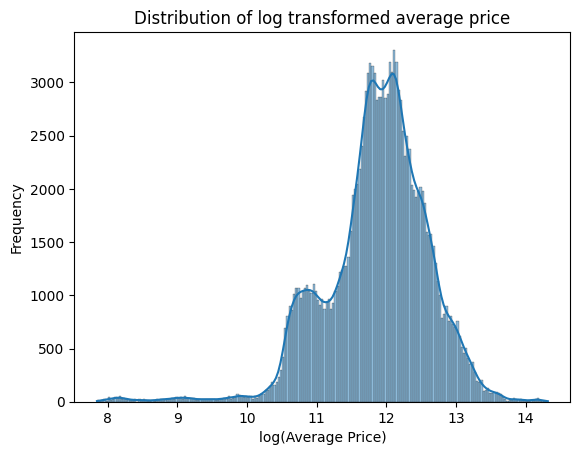

In [459]:
# Log transforming to compress large values to reduce skewness, stabilising variance and improving model performance, then visualising the results in another histogram

df["LogAveragePrice"] = np.log(df["AveragePrice"] +1) #add 1 to avoid issues with the log
sns.histplot(df["LogAveragePrice"], kde = True)
plt.title("Distribution of log transformed average price")
plt.xlabel("log(Average Price)")
plt.ylabel("Frequency")

The long tail has compressed, and the shape is closer to symmetric 

In [460]:
#Extracting date / time features in order to capture the time-dependent factors affecting housing prices: 
# Year: captures long term trends, Month: captures seasonality, Day of the week: can capture weekday/weekend effects, Quarter: asummary of seasonality by quarters, Day of year: more granular seasonal patterns

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["DayOfWeek"] += 1
df["Quarter"] = df["Date"].dt.quarter
df["DayOfYear"] = df["Date"].dt.dayofyear
df.drop(columns = ["Date"])
df["Quarter"]

0         1
1         1
2         1
3         2
4         2
         ..
145840    4
145841    1
145842    1
145843    1
145844    2
Name: Quarter, Length: 145845, dtype: int32

In [461]:
df.head()

,Date,RegionName,AreaCode,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,...,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume,LogAveragePrice,Year,Month,DayOfWeek,Quarter,DayOfYear
0,2004-01-01,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,NaN,NaN,388.0,...,41.0,NaN,NaN,285.0,11.346150,2004,1,4,1,1
1,2004-02-01,Aberdeenshire,S12000034,84623,41.1,NaN,0.0,NaN,NaN,326.0,...,40.9,-0.1,NaN,219.0,11.345973,2004,2,7,1,32
2,2004-03-01,Aberdeenshire,S12000034,86536,42.1,NaN,2.3,NaN,NaN,453.0,...,41.9,2.4,NaN,313.0,11.368327,2004,3,1,1,61
3,2004-04-01,Aberdeenshire,S12000034,87373,42.5,NaN,1.0,NaN,NaN,571.0,...,42.5,1.3,NaN,391.0,11.377953,2004,4,4,2,92
4,2004-05-01,Aberdeenshire,S12000034,89493,43.5,NaN,2.4,NaN,NaN,502.0,...,43.6,2.6,NaN,335.0,11.401927,2004,5,6,2,122


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8'),
  Text(8, 0, '9'),
  Text(9, 0, '10'),
  Text(10, 0, '11'),
  Text(11, 0, '12')])

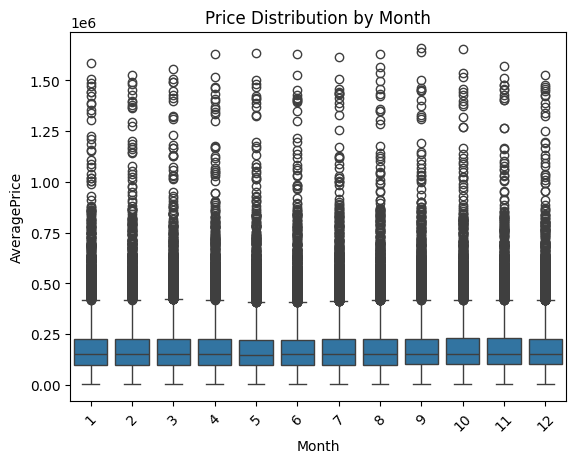

In [462]:
#Visualisation of date/time features with price 
#Box plot of price by month to see how prices vary month to month over the 2 years 
sns.boxplot(x = "Month", y = "AveragePrice", data=df)
plt.title("Price Distribution by Month")
plt.xticks(rotation = 45)

Text(0.5, 1.0, 'Price Distribution by Month')

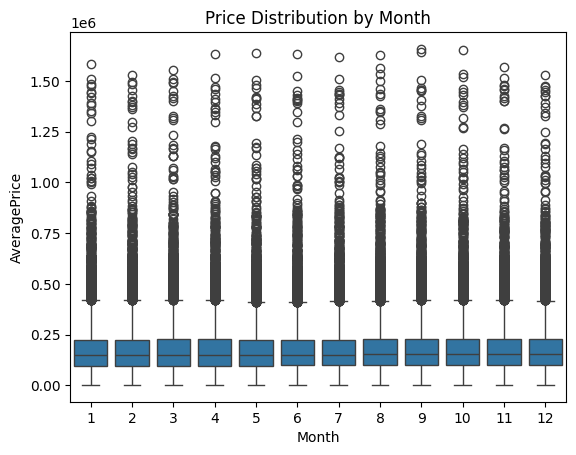

In [463]:
#Visualisation of date/time features with price 
#Box plot of price by month to see how prices vary seasonally, hiding any yearly trend
sns.boxplot(x = "Month", y = "AveragePrice", data=df)
plt.title("Price Distribution by Month")

Compute correlations, to see how strongly each feature relates to the target variable (price), and how features relate to each other, to further guide feature selection and modeling. 

Categorised Variable Summary: 
- Target-like / Leaky variables which should be excluded as predictors: 
'DetachedPrice','SemiDetachedPrice','TerracedPrice','FlatPrice','NewPrice','OldPrice'
- Price-Derived INdices which are usually calculated from prices 
'DetachedIndex','SemiDetachedIndex','TerracedIndex','FlatIndex','NewIndex','OldIndex','Index'
- Change %, Volume, and Market Signals which reflect market dynamics and can be used to explain or predict price trends
'1m%Change','12m%Change','SalesVolume','Detached1m%Change','Detached12m%Change','SemiDetached1m%Change','SemiDetached12m%Change','Terraced1m%Change','Terraced12m%Change','Flat1m%Change','Flat12m%Change','New1m%Change','New12m%Change','NewSalesVolume','Old1m%Change','Old12m%Change','OldSalesVolume'
- Temporal features 
- Categorical features which need one hot encoding 
'RegionName', 'AreaCode'

In [464]:
#Target variable is "AveragePrice", excluding categorical variables and leaky variables above

# Drop the leaky columns
leaky_cols = [
    'AveragePrice', 'LogAveragePrice',
    'DetachedPrice', 'SemiDetachedPrice', 'TerracedPrice', 'FlatPrice',
    'NewPrice', 'OldPrice', 'MortgagePrice', 'FOOPrice', 'CashPrice', 'FTBPrice'
]

df_encoded = df.drop(columns=leaky_cols)

#calculate correlations
numeric_df = df_encoded.select_dtypes(include = ["number"])
correlations = numeric_df.corrwith(df["AveragePrice"]).sort_values(ascending =False)
correlations

AveragePriceSA            0.999836
IndexSA                   0.692373
Index                     0.606891
NewIndex                  0.605535
OldIndex                  0.597960
TerracedIndex             0.586277
SemiDetachedIndex         0.584241
Year                      0.581569
DetachedIndex             0.579913
FlatIndex                 0.573616
FTBIndex                  0.423873
CashIndex                 0.418301
MortgageIndex             0.413109
FOOIndex                  0.404275
Quarter                   0.012029
DayOfYear                 0.011990
Month                     0.011918
DayOfWeek                 0.001900
FOO1m%Change             -0.005025
FTB1m%Change             -0.006994
Mortgage1m%Change        -0.007205
Cash1m%Change            -0.007327
SalesVolume              -0.013112
OldSalesVolume           -0.014025
NewSalesVolume           -0.014916
MortgageSalesVolume      -0.017097
FOO12m%Change            -0.022348
FTB12m%Change            -0.023801
CashSalesVolume     

Summary: 
The target variable for prediction is **`AveragePrice`**.

Objective: 
Identify which numerical variables have a meaningful linear relationship with `AveragePrice` and to detect any signs of multicollinearity or data leakage that could affect modeling.

Key Findings: 

#### Very Weak or No Correlation (|r| < 0.05):
- `Year`, `Month`, `Quarter`, `DayOfWeek`, `DayOfYear`  
These temporal variables show little to no linear correlation with average house price.  
However, they may still capture **seasonal effects** or **nonlinear trends** if encoded differently (e.g. one-hot encoding or cyclical transformation).

#### Mild Negative Correlation (|r| ~ 0.05–0.20):
- `1m%Change`, `DetachedIndex`, `FlatIndex`, `SalesVolume`, `NewSalesVolume`, etc.  
These show a weak inverse relationship with price — possibly indicating mild market adjustments or that higher sales volumes occur in lower-priced regions.

#### Moderate Negative Correlation (|r| > 0.20):
- `12m%Change` and all housing-type-specific 12-month change variables:
  - `Flat12m%Change` (–0.22), `Terraced12m%Change` (–0.22), `Detached12m%Change` (–0.21), etc.  
This suggests that higher year-on-year price growth may be followed by cooling prices — potentially indicating **mean reversion** in the market.  
These are valuable features for further exploration.

#### Index Variables (e.g., `Index`, `FlatIndex`)
- Moderate negative correlation observed (e.g., `Index`: –0.31)  
These indices are **derived from prices** and thus **excluded** from model features to avoid data leakage.

---

### Conclusion:
- Most linear correlations with `AveragePrice` are weak or negative.
- Strongly correlated sub-price variables (`DetachedPrice`, `FlatPrice`, etc.) were excluded from this analysis due to their **leakage risk**.
- **12-month % change variables** are the most informative numeric predictors, though in a negative direction.
- Further modeling will explore **nonlinear relationships**, **categorical encodings**, and **lagged features** to improve predictive power.

In [465]:
#Setting the target variable to the log-transformed price 
y = df["LogAveragePrice"]

In [466]:
#One-hot encoding on categorical columns 
df_encoded = pd.get_dummies(df_encoded,columns = ["RegionName", "AreaCode"], drop_first = True)
df_encoded = df_encoded.drop(columns = ["Date"])

In [467]:
#Create feature matrix
X = df_encoded

In [468]:
# Find all Period dtype columns and drop 
period_cols = [col for col in df_encoded.columns if isinstance(df_encoded[col].dtype, pd.PeriodDtype)]

df_encoded contains all numerical columns + categorical columns which have been one-hot encoded with one dummy per categorical variable dropped to avoid multicollinearity 

In [469]:
# Identify numeric columns
num_cols = df_encoded.select_dtypes(include=['number']).columns.tolist()

In [470]:
df_encoded

,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,DetachedIndex,Detached1m%Change,Detached12m%Change,SemiDetachedIndex,...,AreaCode_W06000015,AreaCode_W06000016,AreaCode_W06000018,AreaCode_W06000019,AreaCode_W06000020,AreaCode_W06000021,AreaCode_W06000022,AreaCode_W06000023,AreaCode_W06000024,AreaCode_W92000004
0,41.1,NaN,NaN,NaN,NaN,388.0,43.2,NaN,NaN,40.9,...,False,False,False,False,False,False,False,False,False,False
1,41.1,NaN,0.0,NaN,NaN,326.0,42.7,-1.0,NaN,41.1,...,False,False,False,False,False,False,False,False,False,False
2,42.1,NaN,2.3,NaN,NaN,453.0,43.5,1.7,NaN,42.2,...,False,False,False,False,False,False,False,False,False,False
3,42.5,NaN,1.0,NaN,NaN,571.0,43.1,-0.9,NaN,43.2,...,False,False,False,False,False,False,False,False,False,False
4,43.5,NaN,2.4,NaN,NaN,502.0,43.9,1.8,NaN,44.5,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145840,105.9,105.3,-0.1,5.4,201690.0,4922.0,104.8,0.4,5.3,106.1,...,False,False,False,False,False,False,False,False,False,False
145841,105.2,105.4,-0.7,5.2,201908.0,3672.0,103.9,-0.9,4.4,105.7,...,False,False,False,False,False,False,False,False,False,False
145842,107.9,108.0,2.6,8.2,206906.0,4171.0,106.8,2.8,8.5,108.2,...,False,False,False,False,False,False,False,False,False,False
145843,110.9,111.3,2.8,10.2,213200.0,NaN,107.8,0.9,8.0,111.6,...,False,False,False,False,False,False,False,False,False,False


In [471]:
# 1. Split first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train

# 2. Numeric imputer (fit only on training set)
num_imputer = SimpleImputer(strategy='median')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])  # Use same median values


In [472]:
#Get the list of safe numeric column names 
safe_numeric_cols = df_encoded.columns.tolist()
safe_numeric_cols


['Index',
 'IndexSA',
 '1m%Change',
 '12m%Change',
 'AveragePriceSA',
 'SalesVolume',
 'DetachedIndex',
 'Detached1m%Change',
 'Detached12m%Change',
 'SemiDetachedIndex',
 'SemiDetached1m%Change',
 'SemiDetached12m%Change',
 'TerracedIndex',
 'Terraced1m%Change',
 'Terraced12m%Change',
 'FlatIndex',
 'Flat1m%Change',
 'Flat12m%Change',
 'CashIndex',
 'Cash1m%Change',
 'Cash12m%Change',
 'CashSalesVolume',
 'MortgageIndex',
 'Mortgage1m%Change',
 'Mortgage12m%Change',
 'MortgageSalesVolume',
 'FTBIndex',
 'FTB1m%Change',
 'FTB12m%Change',
 'FOOIndex',
 'FOO1m%Change',
 'FOO12m%Change',
 'NewIndex',
 'New1m%Change',
 'New12m%Change',
 'NewSalesVolume',
 'OldIndex',
 'Old1m%Change',
 'Old12m%Change',
 'OldSalesVolume',
 'Year',
 'Month',
 'DayOfWeek',
 'Quarter',
 'DayOfYear',
 'RegionName_Adur',
 'RegionName_Amber Valley',
 'RegionName_Angus',
 'RegionName_Antrim and Newtownabbey',
 'RegionName_Ards and North Down',
 'RegionName_Argyll and Bute',
 'RegionName_Armagh City Banbridge and Cr

In [473]:
#Initialise Powertransformer with method "yeo-johnson"
pt = PowerTransformer(method = "yeo-johnson")

#Fit transformer on numeric columns of training data and transform them 
X_train[safe_numeric_cols] = pt.fit_transform(X_train[safe_numeric_cols])

In [474]:
#Fit transformer on numeric columns of testing data and transform them, directly applying the optimised trasnformation learned from the training dataset
X_test[safe_numeric_cols] = pt.transform(X_test[safe_numeric_cols])

In [475]:
#Modeling with Linear Regression

#Initialise model 
model = LinearRegression()

#Fit on training data
model.fit(X_train, y_train)

#Predict on test data 
y_pred = model.predict(X_test)

#Evaluate 
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")


Mean Squared Error: 0.02
R^2 Score: 0.96


Mean Squared Error: 0.22
R^2 Score: 0.58


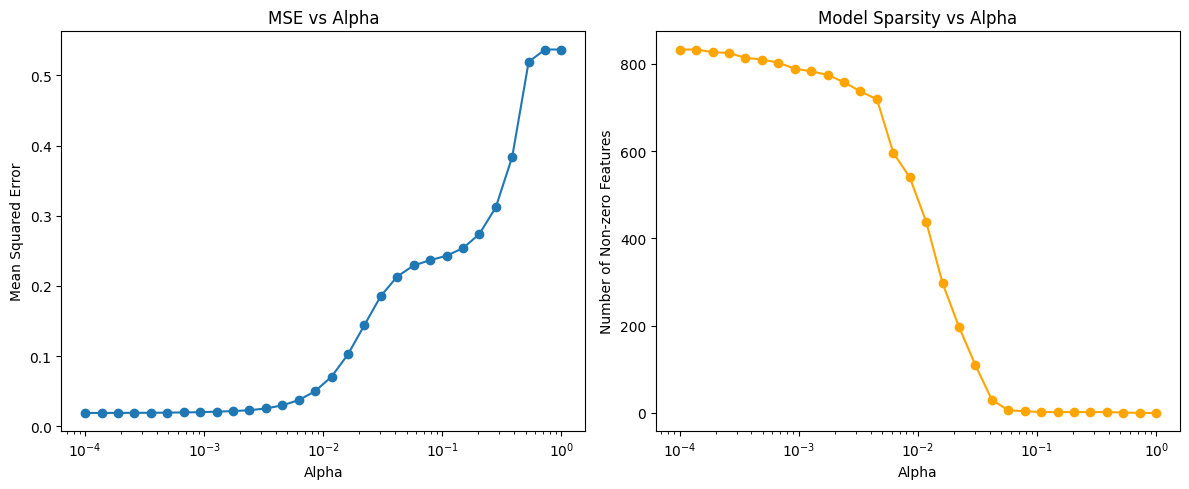

In [476]:
#Initialise Lasso model with alpha = 0.1
model = Lasso(alpha = 0.05)

#Fit model on training data 
model.fit(X_train, y_train)

#Predict on test data 
y_pred = model.predict(X_test)

#Evaluate predictions 
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

#Tune hyperparameter alpha through systematic looping 
alphas = np.logspace(-4, 0, 30)  # 30 values from 0.0001 to 1
mse_list = []
r2_list = []
nonzero_features = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=10000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse_list.append(mean_squared_error(y_test, y_pred))
    r2_list.append(r2_score(y_test, y_pred))
    nonzero_features.append(np.sum(model.coef_ != 0))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(alphas, mse_list, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('MSE vs Alpha')

plt.subplot(1, 2, 2)
plt.plot(alphas, nonzero_features, marker='o', color='orange')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Number of Non-zero Features')
plt.title('Model Sparsity vs Alpha')

plt.tight_layout()
plt.show()

In [477]:
#Access the model's learned coefficient 

coef_df = pd.DataFrame({
    "Feature" : X_train.columns,
    "Coefficient": model.coef_
})

print(coef_df.sort_values(by = "Coefficient", key= abs, ascending = False))
print(f"Total non zero features: {sum(model.coef_ != 0)}")

                               Feature  Coefficient
0                                Index          0.0
561                 AreaCode_E07000091          0.0
563                 AreaCode_E07000093          0.0
564                 AreaCode_E07000094          0.0
565                 AreaCode_E07000095          0.0
..                                 ...          ...
287           RegionName_North Norfolk          0.0
288  RegionName_North Northamptonshire         -0.0
289          RegionName_North Somerset          0.0
290          RegionName_North Tyneside         -0.0
852                 AreaCode_W92000004         -0.0

[853 rows x 2 columns]
Total non zero features: 0


In [478]:
#Hyperparameter tuning using Cross-validation for reliable evaluation to average the model's performance over multiple splits, giving a more robust and reliable estimate of how well it can perform on unseen data 

model = Lasso(max_iter = 1000)

#Define a range for the alpha values to test using cross-validation 
param_grid = {
    "alpha": [0.0001,0.001,0.01,0.1]
} 

#Set up the GridSearchCV 
grid_search = GridSearchCV(
    estimator = model, 
    param_grid = param_grid, 
    scoring = "neg_mean_squared_error", #minimise MSE
    cv = 5, #5-fold cross-validation 
    n_jobs = -1 #use all CPU scores 
)

grid_search.fit(X_train, y_train)

print(f"Best alpha: {grid_search.best_params_["alpha"]}")
print(f"Best CV MSE: {-grid_search.best_score_: .4f}") #negate since score is negative MSE 

/Users/lydialichen/real_estate/real-estate-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.408e+02, tolerance: 4.999e+00
  model = cd_fast.enet_coordinate_descent(
/Users/lydialichen/real_estate/real-estate-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.276e+01, tolerance: 5.022e+00
  model = cd_fast.enet_coordinate_descent(
/Users/lydialichen/real_estate/real-estate-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of i

Best alpha: 0.0001
Best CV MSE:  0.0191


/Users/lydialichen/real_estate/real-estate-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.052e+02, tolerance: 6.272e+00
  model = cd_fast.enet_coordinate_descent(


In [479]:
#Use the model to predict and evaluate on test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

#Evaluate: final test performance metrics 
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.4f}")
print(f"Test R^2: {r2:.4f}")

Test MSE: 0.0189
Test R^2: 0.9648


In [480]:
#Analyse Feature importance with Lasso 

#Extract coefficients from the best model 
coefficients = best_model.coef_ 

#Map coefficients to feature names 
feature_names = X_train.columns 
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

#Filter non_zero coefficients 
important_features = coef_df[coef_df['Coefficient'] != 0]

#Sort by absolute value of coefficient descending 
important_features = important_features.reindex(important_features['Coefficient'].abs().sort_values(ascending = False).index)

#Most important features
print(important_features)

                Feature  Coefficient
0                 Index     0.878134
12        TerracedIndex    -0.635602
15            FlatIndex     0.291771
19        Cash1m%Change    -0.144757
14   Terraced12m%Change     0.110282
..                  ...          ...
667  AreaCode_E07000239    -0.000015
517  AreaCode_E07000034    -0.000013
457  AreaCode_E06000010    -0.000011
516  AreaCode_E07000033    -0.000008
462  AreaCode_E06000015    -0.000005

[836 rows x 2 columns]


In [ ]:
#Save model for later use 
joblib.dump(best_model, 'models/lasso_best_model.joblib')


['lasso_best_model.joblib']

In [482]:
#Final Summary 

#Evaluate: final test performance metrics 
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.4f}")
print(f"Test R^2: {r2:.4f}")

#Most important features
print(important_features)

Test MSE: 0.0189
Test R^2: 0.9648
                Feature  Coefficient
0                 Index     0.878134
12        TerracedIndex    -0.635602
15            FlatIndex     0.291771
19        Cash1m%Change    -0.144757
14   Terraced12m%Change     0.110282
..                  ...          ...
667  AreaCode_E07000239    -0.000015
517  AreaCode_E07000034    -0.000013
457  AreaCode_E06000010    -0.000011
516  AreaCode_E07000033    -0.000008
462  AreaCode_E06000015    -0.000005

[836 rows x 2 columns]


In [490]:
#Create pipeline for preprocessing steps

#Define custom transformer for dropping columns 
class DropColumnsTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X = X.drop(columns=self.columns_to_drop, errors='ignore')
        period_cols = [col for col in X.columns if isinstance(X[col].dtype, pd.PeriodDtype)]
        X = X.drop(columns=period_cols, errors='ignore')
        return X
    
# Columns to drop (leaky + others)
leaky_cols = [
    'AveragePrice', 'LogAveragePrice',
    'DetachedPrice', 'SemiDetachedPrice', 'TerracedPrice', 'FlatPrice',
    'NewPrice', 'OldPrice', 'MortgagePrice', 'FOOPrice', 'CashPrice', 'FTBPrice'
]

# Features and target from original df
X = df.drop(columns=['AveragePrice'])  # Drop target column
y = df['AveragePrice']

# Define categorical and numeric columns from original df
categorical_cols = ['RegionName', 'AreaCode']
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
# Remove categorical and leaky columns if they appear in numeric_cols
numeric_cols = [col for col in numeric_cols if col not in categorical_cols + leaky_cols]

# Numerical pipeline: impute then scale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),       # or 'median'
    ('scaler', PowerTransformer())
])

# Categorical pipeline: impute then encode
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Combine both
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_cols),
    ('cat', cat_pipeline, categorical_cols)
])

# Create full pipeline: preprocessing + model
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', model)
])

# Fit the pipeline
pipeline.fit(X, y)

# Save pipeline
joblib.dump(pipeline, '/Users/lydialichen/real_estate/real-estate-ml/models/pipeline.pkl')


/Users/lydialichen/real_estate/real-estate-ml/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.118e+14, tolerance: 2.447e+11
  model = cd_fast.enet_coordinate_descent(


['/Users/lydialichen/real_estate/real-estate-ml/models/pipeline.pkl']